In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk import PorterStemmer
from sklearn.model_selection import train_test_split
import collections
import json

# Spam Filter Tutorial Naive Bayesian Classifiers

In this part you are going to implement the naive bayesian classifier with scikit-learn.

## Dataset

First we load the dataset similarly to the previous tutorial.

In [2]:
data = pd.read_csv('spam.csv', encoding = 'latin-1')
data.drop(columns=['Unnamed: 2', 'Unnamed: 3','Unnamed: 4'], inplace=True)
data.rename(columns={'v1': 'spam', 'v2' : 'content'}, inplace=True)
data['spam'] = data['spam'].apply(lambda x: True if x == 'spam' else False)
data.head()

,spam,content
0,False,"Go until jurong point, crazy.. Available only ..."
1,False,Ok lar... Joking wif u oni...
2,True,Free entry in 2 a wkly comp to win FA Cup fina...
3,False,U dun say so early hor... U c already then say...
4,False,"Nah I don't think he goes to usf, he lives aro..."


Lets first see how many of the emails in the dataset are spam.

In [3]:
data['spam'].value_counts()

spam
False    4825
True      747
Name: count, dtype: int64

### Train test split
And make a train test split so we can train the model on the training dataset and evaluate its accuracy on the test dataset. Note that 'training' in Naïve Bayes reference to computing probabilites.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(data['content'], data['spam'], test_size=0.33, random_state=42)

### Visualize data

In order to classify the emails correctly we are going to make use of the individual words in the emails. For example, "password" may be an indication of a Fishing email, while the name of a friend of family member may be an indication of a normal email. Below the word counts of individual words (features) are visualized.

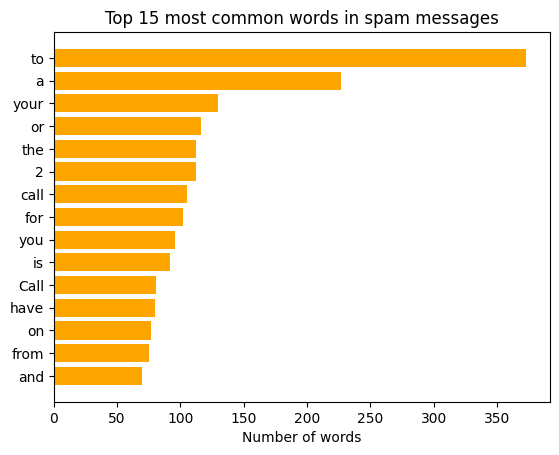

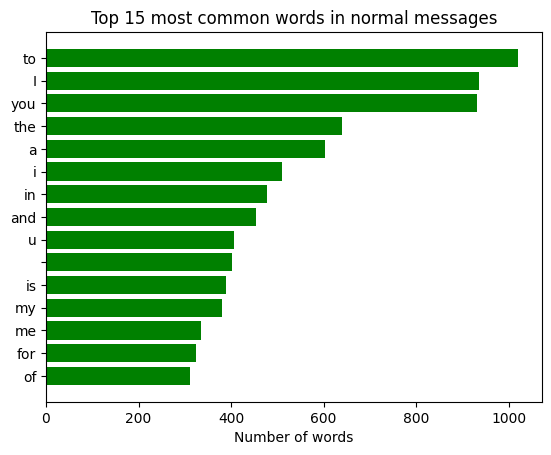

In [5]:
def count_words(data):
    counter = collections.OrderedDict()
    for message in data:
        for word in message.split(' '):
            if word in counter:
                counter[word] += 1
            else:
                counter[word] = 1
    return counter

spam_messages = set(X_train[y_train == True])
spam_words = count_words(spam_messages)
normal_messages = set(X_train[y_train == False])
normal_words = count_words(normal_messages)

def bar_chart_words(words, top=10, messages_type="", color="#1f77b4"):
    top_spam = np.array(sorted(words.items(), key=lambda x: -x[1]))[:top]
    top_words = top_spam[ : :-1, 0]
    top_words_count = [int(i) for i in top_spam[ : :-1, 1]]
    # aesthetics
    if messages_type:
        messages_type = messages_type + " "
    plt.title(f"Top {top} most common words in {messages_type}messages")
    plt.xlabel(f"Number of words")
    plt.barh(top_words, top_words_count, color=color)
    plt.show()

bar_chart_words(spam_words, top=15, messages_type="spam", color="orange")
bar_chart_words(normal_words, top=15, messages_type="normal", color="green")

### Preprocessing text data

We take similar steps for preprocessing. However, the vectorizor in the next step needs a string rather then a list of words as input.

TODO: adjust the preprocess_content() function so it gives back a string of words rather then a list of words.


In [6]:
#load english wordlist
with open('words_dictionary.json', 'r') as file:
    wordlist = list(json.load(file).keys())

#load english stopwords
with open('stopwords.txt', 'r') as file:
    stop_words = [line.strip() for line in file]

#function to preprocess email content
def preprocess_content(content):
    words = content.lower() #lowercase
    words = words.split() #tokenize by spaces
    words = [word for word in words if len(word) > 1] # remove words of one letter, since these are generally not informative
    words = [word for word in words if word not in stop_words] # remove stopwords
    words = [word for word in words if word in wordlist] # remove non English words
    words = [PorterStemmer().stem(word) for word in words] # Apply stemming

    # return a string

    return words

## wordcounts

TODO: apply the preprocess function to the training and text data

In [7]:
# preprocess data

Next we need to get the wordcounts as input for the classifier. We use CountVectorizer for this.

TODO: use CountVectorizer to transform X_Train and X_test into wordcount arrays.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer


TODO: visualize the resulting feature names (words) and count array.

In [9]:
# feature names


In [10]:
# feature counts


# fit model

Now we can fit the model. Since we have a list of features we use the Multinomial variant for this.

TODO: fit multinomialNB() on the preprocessed wordcounts training data.

In [11]:
from  sklearn.naive_bayes import MultinomialNB

# fit model

# evaluate model

Lastly we evaluate the model.

TODO: compute the number of correct and wrong classifictions on the test set.

In [12]:
# copute correct and wrongly classified instances

TODO: print the first 10 wrongly classified messages.

In [13]:
# print first 10 wrongly classified messages

TODO: show the classification report

In [14]:
from sklearn.metrics import classification_report

# print classification report